# Phase 5.3 — Alert Gating + Dedup + Rate Limiting (SOC Engineering)

Phase 5.2 produced an interpretable anomaly score (`anomaly_score`).
However, raw thresholding is operationally unsafe.

Goal of Phase 5.3:
Convert detection signals into SOC-usable alerts by adding:

1) Threshold gating (signal candidate)
2) Deduplication (suppression window)
3) Rate limiting (storm control)
4) Severity scoring (analyst queue prioritization)

Primary evaluation:
- alerts before vs after gating
- reduction ratio
- drift-aware alert behavior per `source_file`

We do NOT optimize for ML metrics (accuracy/F1/ROC).


## 1) Setup & Output Directories (Phase 5 enforced)

All artifacts must save inside Phase 5:

- outputs/tables/
- outputs/figures/


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

PHASE5_DIR = r"D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5"

OUTPUT_DIR = os.path.join(PHASE5_DIR, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)


FIG_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures
TAB_DIR: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables


## 2) Load CICIDS (Split Files) + minimal preprocessing

We keep the multi-file structure and `source_file` column so alert behavior remains drift-aware.


In [2]:
DATA_DIR = r"D:\MachineLearningCVE"

FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

paths = [os.path.join(DATA_DIR, f) for f in FILES]

dfs = []
for p in paths:
    df_part = pd.read_csv(p, low_memory=False)
    df_part.columns = [c.strip() for c in df_part.columns]
    df_part["source_file"] = os.path.basename(p)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


In [3]:
df.columns = [c.strip() for c in df.columns]

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

label_candidates = ["Label", "label", "Class", "class", "Attack", "attack"]
label_col = next((c for c in label_candidates if c in df.columns), None)
assert label_col is not None, "Label column not found."

df[label_col] = df[label_col].astype(str).str.strip()

benign_values = ["BENIGN", "Benign", "benign", "Normal", "NORMAL"]


## 3) Recompute anomaly_score (same as Phase 5.2)

We reproduce the MAD-based scoring logic so Phase 5.3 is standalone and reproducible.


In [4]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
]

def mad(x: pd.Series):
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    med = x.median()
    return (x - med).abs().median()

df_benign = df[df[label_col].isin(benign_values)].copy()

baseline_params = []
for f in features:
    x = pd.to_numeric(df_benign[f], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    baseline_params.append({"feature": f, "median": x.median(), "mad": mad(df_benign[f])})

def robust_z(series: pd.Series, median: float, mad_val: float, eps: float = 1e-9):
    x = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return (x - median).abs() / (mad_val + eps)

for row in baseline_params:
    f = row["feature"]
    df[f"rz_{f}"] = robust_z(df[f], row["median"], row["mad"])

rz_cols = [c for c in df.columns if c.startswith("rz_")]
df["anomaly_score"] = df[rz_cols].max(axis=1, skipna=True)

df["anomaly_score"].describe()


count    2.830743e+06
mean     1.228600e+03
std      5.522893e+03
min      2.642944e-02
25%      7.780576e+00
50%      2.036838e+02
75%      6.775204e+02
max      4.021527e+05
Name: anomaly_score, dtype: float64

## 4) Choose operational threshold (SOC gating knob)

We select one BENIGN quantile as primary operational threshold.
Recommended default for Phase 5.3 gating experiments: **p99.5**


In [5]:
df_benign = df[df[label_col].isin(benign_values)].copy()
df_attack = df[~df[label_col].isin(benign_values)].copy()

thresholds = {
    "p99": df_benign["anomaly_score"].quantile(0.99),
    "p995": df_benign["anomaly_score"].quantile(0.995),
    "p999": df_benign["anomaly_score"].quantile(0.999),
}

thresholds


{'p99': 16373.958700632218,
 'p995': 16373.958700632218,
 'p999': 60001.64999831227}

In [6]:
THRESHOLD_NAME = "p995"
THRESHOLD_VALUE = thresholds[THRESHOLD_NAME]
THRESHOLD_VALUE


16373.958700632218

## 5) Signal Candidates (alerts BEFORE gating)

A signal candidate is any flow with:
`anomaly_score >= threshold`

This is not a real alert yet.
This is the raw detector output.


In [7]:
df["signal_candidate"] = df["anomaly_score"] >= THRESHOLD_VALUE

before_count = int(df["signal_candidate"].sum())
before_rate = float(df["signal_candidate"].mean())

before_count, before_rate


(33004, 0.011659129776175371)

## 6) Entity grouping keys (SOC alert grouping)

SOC alerts are grouped per entity/service.

Preferred grouping:
- Src IP (entity)
- Dst Port (service)
- Protocol (if available)

Fallback if missing:
- use available subset + source_file


In [8]:
def safe_col(name):
    return name if name in df.columns else None

SRC = safe_col("Src IP")
DSTPORT = safe_col("Dst Port")
PROTO = safe_col("Protocol")

group_cols = [c for c in [SRC, DSTPORT, PROTO, "source_file"] if c is not None]
group_cols


['source_file']

In [9]:
df["group_key"] = df[group_cols].astype(str).agg("|".join, axis=1)
df["group_key"].head()


0    Monday-WorkingHours.pcap_ISCX.csv
1    Monday-WorkingHours.pcap_ISCX.csv
2    Monday-WorkingHours.pcap_ISCX.csv
3    Monday-WorkingHours.pcap_ISCX.csv
4    Monday-WorkingHours.pcap_ISCX.csv
Name: group_key, dtype: object

## 7) Deduplication (suppression window)

Deduplication prevents repeated identical alerts from flooding the queue.

We simulate a suppression window (no perfect timestamps):
- dedup within the same `group_key`
- keep only the highest anomaly_score per group

This approximates:
"collapse alert storms into one high-signal event"


In [10]:
candidates = df[df["signal_candidate"]].copy()
candidates.shape


(33004, 88)

In [11]:
# Dedup: keep highest score event per group_key
deduped = candidates.sort_values("anomaly_score", ascending=False).drop_duplicates(subset=["group_key"])

print("Before dedup:", len(candidates))
print("After dedup:", len(deduped))


Before dedup: 33004
After dedup: 8


## 8) Rate limiting per entity (storm control)

Even after deduplication, one entity can dominate.

We simulate rate limiting:
- max N alerts per (Src IP or group_key proxy)

Since timestamps are limited, we approximate by limiting alert count per entity in the dataset slice.

This approximates:
"cap alerts per entity per window"


In [12]:
MAX_ALERTS_PER_ENTITY = 3

entity_col = SRC if SRC is not None else "group_key"

limited = (
    deduped
    .sort_values("anomaly_score", ascending=False)
    .groupby(entity_col, as_index=False)
    .head(MAX_ALERTS_PER_ENTITY)
)

print("After rate limiting:", len(limited))


After rate limiting: 8


## 9) Severity scoring (SOC queue prioritization)

We assign severity buckets based on anomaly_score magnitude.

This is not "ground truth severity":
it is queue prioritization based on signal strength.

Buckets:
- Low / Medium / High / Critical


In [13]:
score = limited["anomaly_score"]

p50 = score.quantile(0.50)
p75 = score.quantile(0.75)
p90 = score.quantile(0.90)

def severity_bucket(x):
    if x >= p90:
        return "Critical"
    elif x >= p75:
        return "High"
    elif x >= p50:
        return "Medium"
    else:
        return "Low"

limited["severity"] = limited["anomaly_score"].apply(severity_bucket)
limited["severity"].value_counts()


severity
High        7
Critical    1
Name: count, dtype: int64

## 10) Alerts before vs after gating (SOC impact)

We compute:
- count reduction ratio
- distribution by source_file
- distribution by severity

This demonstrates operational maturity:
"detector output → SOC-ready alert pipeline"


In [14]:
after_count = len(limited)

summary = pd.DataFrame([{
    "threshold": THRESHOLD_NAME,
    "threshold_value": THRESHOLD_VALUE,
    "alerts_before_gating": before_count,
    "alerts_after_gating": after_count,
    "reduction_ratio": 1 - (after_count / max(before_count, 1))
}])

summary


,threshold,threshold_value,alerts_before_gating,alerts_after_gating,reduction_ratio
0,p995,16373.958701,33004,8,0.999758


In [15]:
# Post-gating breakdown: BENIGN vs ATTACK
benign_after = int(limited[label_col].isin(benign_values).sum())
attack_after = int((~limited[label_col].isin(benign_values)).sum())

print("✅ Alerts after gating:", len(limited))
print("✅ BENIGN alerts after gating:", benign_after)
print("✅ ATTACK alerts after gating:", attack_after)

limited[label_col].value_counts()


✅ Alerts after gating: 8
✅ BENIGN alerts after gating: 8
✅ ATTACK alerts after gating: 0


Label
BENIGN    8
Name: count, dtype: int64

In [16]:
summary_path = os.path.join(TAB_DIR, "5.3_alerts_before_after_gating.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

alerts_path = os.path.join(TAB_DIR, "5.3_final_alerts_after_gating.csv")
limited.to_csv(alerts_path, index=False)
print("Saved:", alerts_path)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.3_alerts_before_after_gating.csv
Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.3_final_alerts_after_gating.csv


In [17]:
sev_counts = limited["severity"].value_counts().reset_index()
sev_counts.columns = ["severity", "count"]

sev_path = os.path.join(TAB_DIR, "5.3_severity_bucket_counts.csv")
sev_counts.to_csv(sev_path, index=False)
print("Saved:", sev_path)

sev_counts


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.3_severity_bucket_counts.csv


,severity,count
0,High,7
1,Critical,1


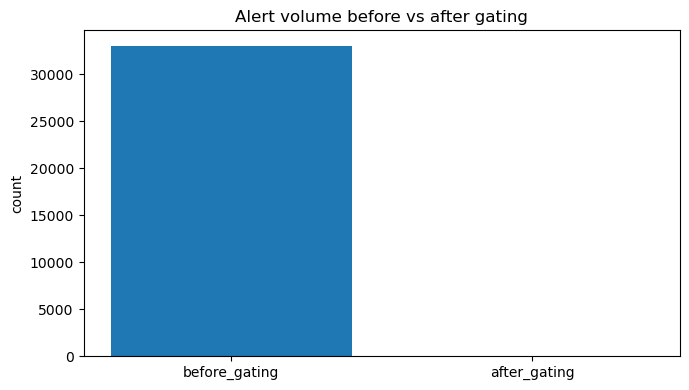

Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\figures\5.3_before_after_alert_volume.png


In [18]:
plt.figure(figsize=(7,4))
plt.bar(["before_gating", "after_gating"], [before_count, after_count])
plt.title("Alert volume before vs after gating")
plt.ylabel("count")
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "5.3_before_after_alert_volume.png")
plt.savefig(fig_path, dpi=220)
plt.show()

print("Saved:", fig_path)


In [19]:
by_file = limited.groupby("source_file").size().reset_index(name="alerts_after_gating").sort_values("alerts_after_gating", ascending=False)
by_file_path = os.path.join(TAB_DIR, "5.3_alerts_after_gating_by_file.csv")
by_file.to_csv(by_file_path, index=False)
print("Saved:", by_file_path)

by_file.head(20)


Saved: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-5\outputs\tables\5.3_alerts_after_gating_by_file.csv


,source_file,alerts_after_gating
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,1
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,1
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,1
3,Monday-WorkingHours.pcap_ISCX.csv,1
4,Thursday-WorkingHours-Afternoon-Infilteration....,1
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,1
6,Tuesday-WorkingHours.pcap_ISCX.csv,1
7,Wednesday-workingHours.pcap_ISCX.csv,1


## Takeaways (Phase 5.3)

- Raw anomaly thresholds produce signal candidates, not safe alerts.
- Deduplication collapses alert storms into fewer high-signal events.
- Rate limiting prevents single entities from dominating analyst workload.
- Severity bucketing creates a prioritized SOC review queue.
- Operational usefulness depends more on gating than detector complexity.

✅ Next: Phase 5.4 investigation packets (why fired + context + actions).
